38


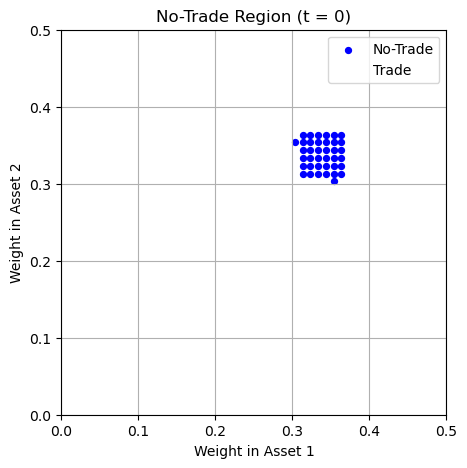

38


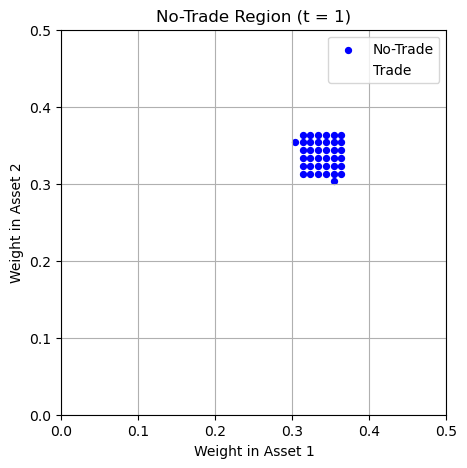

38


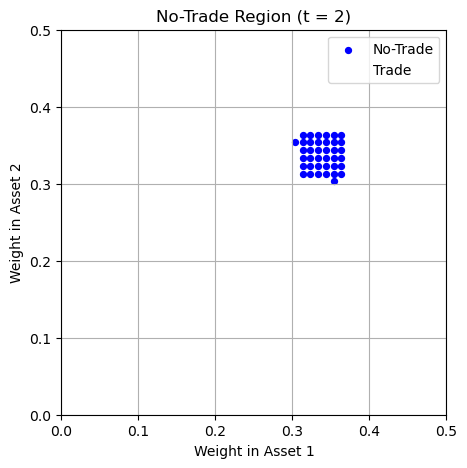

38


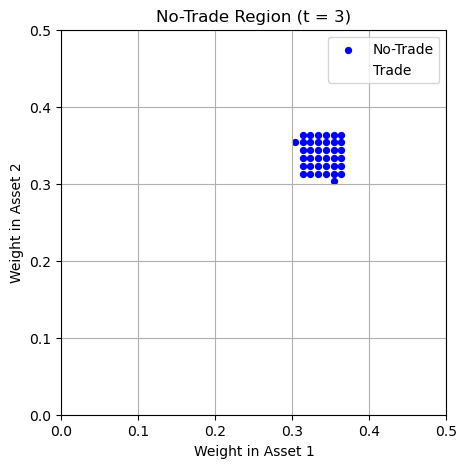

38


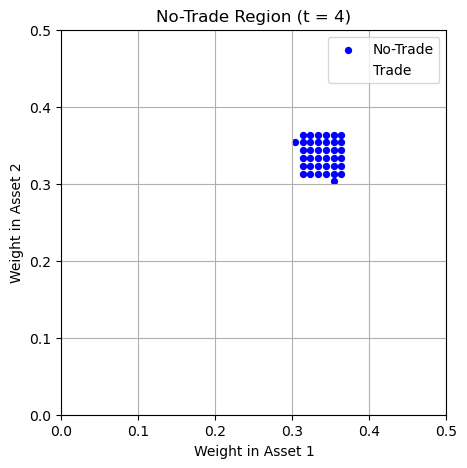

38


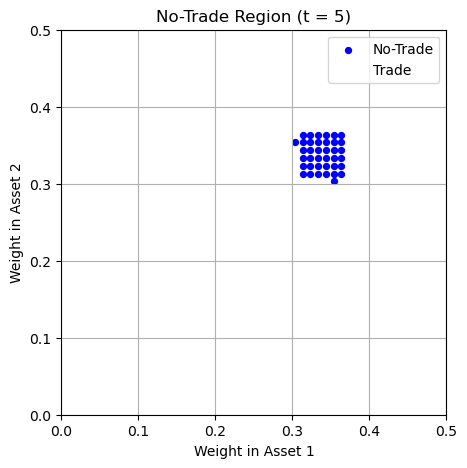

40


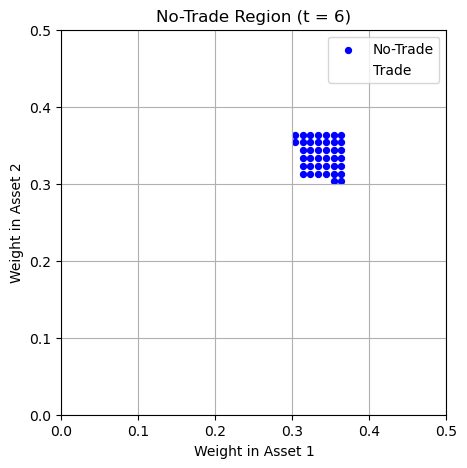

40


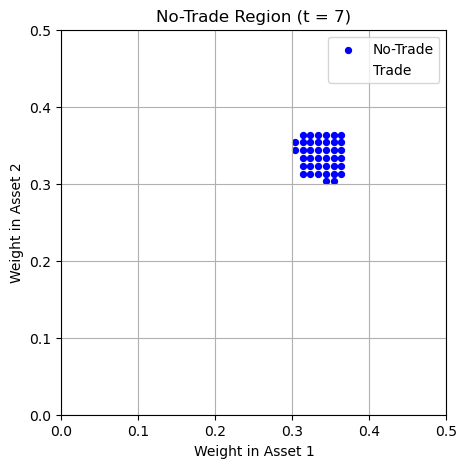

45


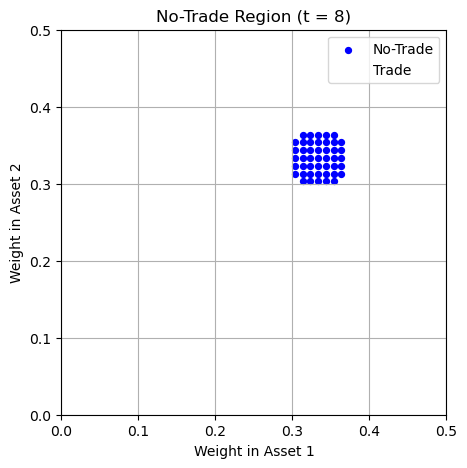

48


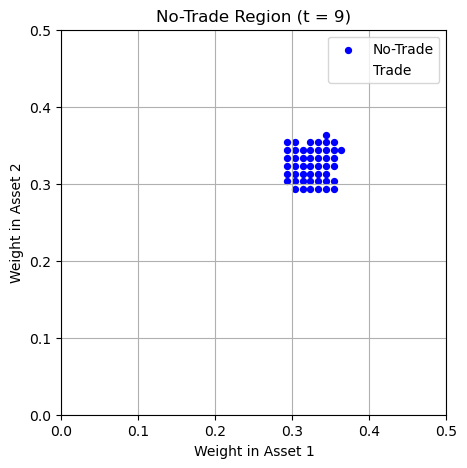

90


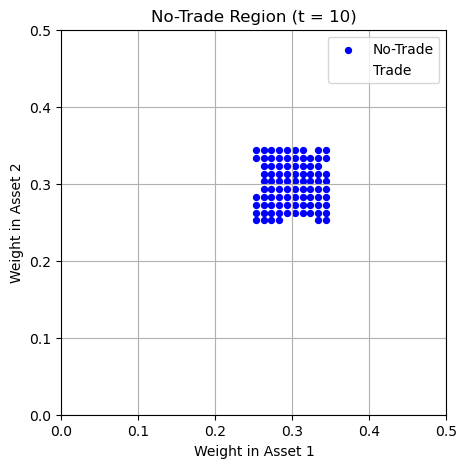

In [2]:
# Added "correct" final utility
import numpy as np
import numba as nb
from scipy.special import roots_hermite
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1.  Parameters
# -------------------------------------------------
T      = 11
beta   = 0.99
gamma  = 3
tau    = 0.005
r      = 0.03

mu_vec    = np.array([0.07, 0.07])
sigma_vec = np.array([0.20, 0.20])
rho       = 0.0
Sigma     = np.array([[sigma_vec[0]**2, rho*sigma_vec[0]*sigma_vec[1]],
                      [rho*sigma_vec[0]*sigma_vec[1], sigma_vec[1]**2]])
Lchol     = np.linalg.cholesky(Sigma).astype(np.float64)        # ensure 64-bit

@nb.njit(cache=True)
def util(c,gamma): 
    '''CRRA utility function'''
    if gamma!=1:
        return (c**(1-gamma))/(1-gamma)
    else:
        return np.log(c)   


# -------------------------------------------------
# 2.  Discretisations
# -------------------------------------------------
n_grid  = 100
w_vals  = np.linspace(0.0, 1.0, n_grid)
grid_w  = np.array([(w1, w2)
                    for w1 in w_vals
                    for w2 in w_vals
                    if w1 + w2 <= 1.0], dtype=np.float64)
n_states = grid_w.shape[0]

# --- fast index table: (i, j) on the n_grid×n_grid lattice → state-index
w_map = -np.ones((n_grid, n_grid), dtype=np.int64)
for k, (w1, w2) in enumerate(grid_w):
    i = int(round(w1*(n_grid-1)))
    j = int(round(w2*(n_grid-1)))
    w_map[i, j] = k                      # every feasible pair is unique

# -------------------------------------------------
# 3.  2-D Gaussian-Hermite rule
# -------------------------------------------------
n_q         = 5
z1d, w1d    = roots_hermite(n_q)
gh_nodes    = np.array([(z1, z2) for z1 in z1d for z2 in z1d], dtype=np.float64)
gh_weights  = np.array([wx*wy          for wx in w1d for wy in w1d], dtype=np.float64)
n_quad      = gh_nodes.shape[0]



# -------------------------------------------------
# 4.  Numba kernels
# -------------------------------------------------
@nb.njit
def exp_continuation_numba(w1p, w2p, Vnext,
                           gh_nodes, gh_weights,
                           mu_vec, L, w_map, n_grid,
                           gamma, r):
    """
    Computes   E_t[ V_{t+1}(w') · R^{1-γ} ]  at weights (w1p,w2p).
    All arrays are already 64-bit, so no copies inside Numba.
    """
    wf   = 1.0 - w1p - w2p
    acc  = 0.0

    for q in range(n_quad):
        z1, z2 = gh_nodes[q, 0], gh_nodes[q, 1]

        # correlated simple returns: μ + √2 L z
        R0 = mu_vec[0] + np.sqrt(2.0)*(L[0,0]*z1 + L[0,1]*z2)
        R1 = mu_vec[1] + np.sqrt(2.0)*(L[1,0]*z1 + L[1,1]*z2)
        g0 = 1.0 + R0
        g1 = 1.0 + R1
        if g0 <= 0.0 or g1 <= 0.0:
            continue

        denom = w1p*g0 + w2p*g1 + wf*(1.0+r)
        w1n   = (w1p*g0)/denom
        w2n   = (w2p*g1)/denom

        # nearest grid point (round onto lattice, then fix if outside simplex)
        i = int(round(w1n*(n_grid-1)))
        j = int(round(w2n*(n_grid-1)))
        s = i + j
        if s > (n_grid-1):             # project back to simplex boundary
            w1n /= w1n + w2n
            w2n  = 1.0 - w1n
            i = int(round(w1n*(n_grid-1)))
            j = int(round(w2n*(n_grid-1)))

        idx = w_map[i, j]
        acc += gh_weights[q] * Vnext[idx] * denom**(1.0 - gamma)

    return acc / np.pi                 # 2-D Hermite scaling


@nb.njit(fastmath=True, cache=True)
def bond_weight_numba(x1, x2, x1n, x2n, tau):
    # NB: all inputs must already be np.float64 arrays or scalars
    trade_cost = tau * (np.abs(x1n - x1) + np.abs(x2n - x2))
    b_t   = 1.0 - x1n - x2n - trade_cost
    return b_t


@nb.njit(parallel=True)
def solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, L,
                beta, gamma, tau, r,
                w_map, n_grid):
    n_states = grid_w.shape[0]
    V = np.zeros((T+1, n_states), dtype=np.float64)
    A = np.zeros((T,   n_states, 2), dtype=np.float64)

    # terminal value
    for s in range(n_states):
        w1, w2 = grid_w[s, 0], grid_w[s, 1]
        cons   = 1.0 - tau*(w1 + w2)              # net consumption at T
        if cons > 0.0:                            # well-defined utility
            V[T, s] = util(cons,gamma)
        else:                                     # infeasible ⇒ very bad
            V[T, s] = -1.0e30

    for t in range(T-1, -1, -1):                 # T-1, …, 0
        Vnext = V[t+1]
        # outer loop parallelised across current states
        for s in nb.prange(n_states):
            w1, w2  = grid_w[s, 0], grid_w[s, 1]

            best_val = -1e30
            best_w1p = w1
            best_w2p = w2

            # feasible trades lie on the same simplex grid
            for a in range(n_states):
                w1p, w2p = grid_w[a, 0], grid_w[a, 1]
                if w1p + w2p > 1.0:
                    continue

                trade = abs(w1p - w1) + abs(w2p - w2)
                cf    = 1.0 - tau*trade                # after fee
                if cf <= 0.0:
                    continue

                cont = exp_continuation_numba(w1p, w2p, Vnext,
                                              gh_nodes, gh_weights,
                                              mu_vec, L, w_map, n_grid,
                                              gamma, r)
                val = (cf**(1.0 - gamma)) * beta * cont

                if val > best_val:
                    best_val = val
                    best_w1p = w1p
                    best_w2p = w2p

            V[t, s]    = best_val
            A[t, s, 0] = best_w1p
            A[t, s, 1] = best_w2p

    return V, A


# -------------------------------------------------
# 5.  Solve and check speed
# -------------------------------------------------
V_opt, A_opt = solve_model(T, grid_w, gh_nodes, gh_weights, mu_vec, Lchol,
                           beta, gamma, tau, r,
                           w_map, n_grid)

# (plotting of NTR is identical to your original script and can
#  reuse V_opt / A_opt directly)
for t in range(T):
    # current grid
    w1a = grid_w[:, 0]
    w2a = grid_w[:, 1]

    # “no–trade’’ indicator (vectorised, tolerance 1 e-12)
    no_trade = (np.isclose(A_opt[t, :, 0], w1a, atol=1e-12) &
                np.isclose(A_opt[t, :, 1], w2a, atol=1e-12))

    plt.figure(figsize=(5, 5))
    print(len(w1a[no_trade]))
    plt.scatter(w1a[no_trade],   w2a[no_trade],   c='blue',   s=18, label='No-Trade')
    plt.scatter(w1a[~no_trade],  w2a[~no_trade],  c='white', marker='x', s=18, label='Trade')
    plt.title(f'No-Trade Region (t = {t})')
    plt.xlabel('Weight in Asset 1'); plt.ylabel('Weight in Asset 2')
    plt.xlim(0, 0.5); plt.ylim(0, 0.5); plt.gca().set_aspect('equal')
    plt.grid()
    plt.legend(); plt.show()


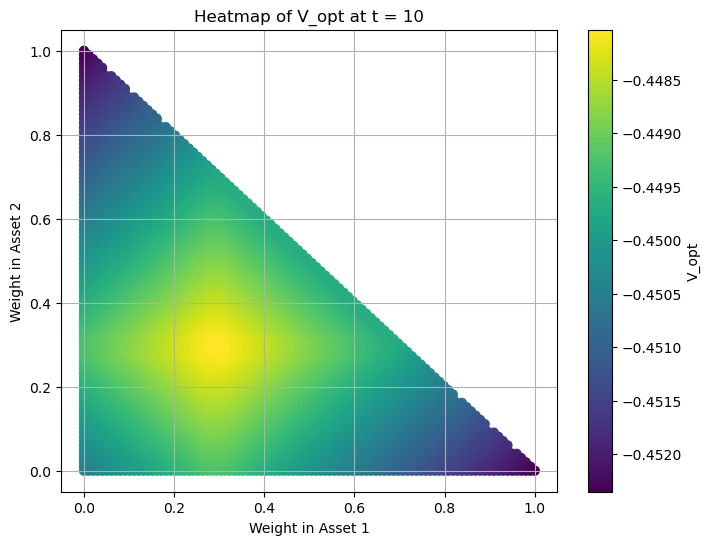

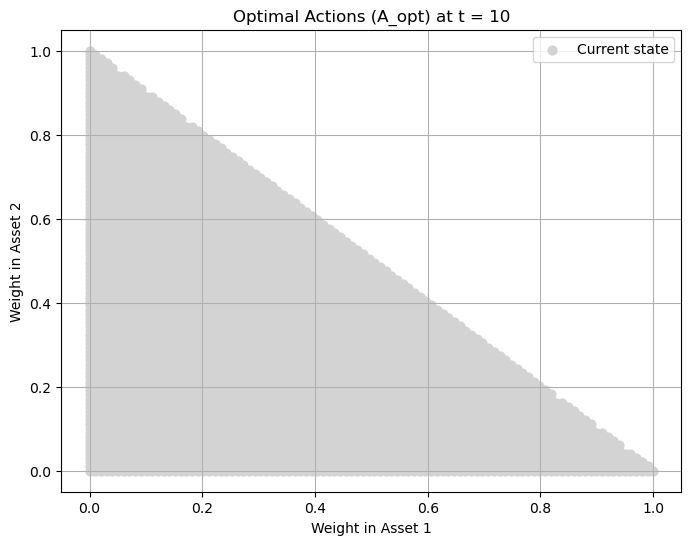

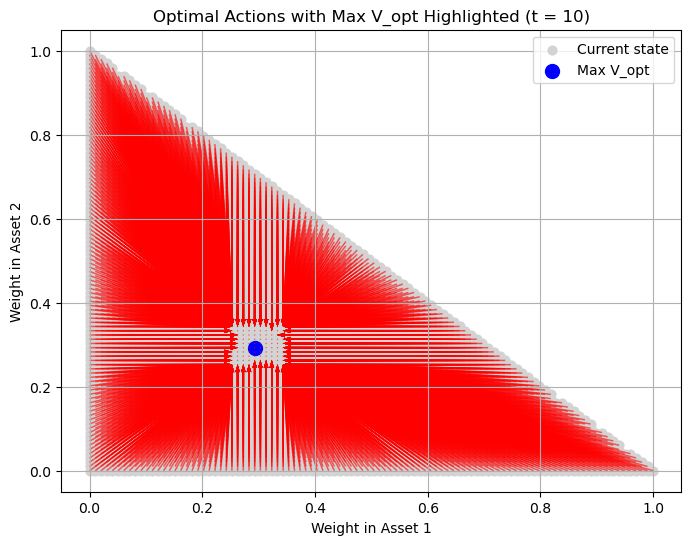

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Choose the time step for analysis (you can change this as needed)
t_plot = 10

# ---------------------------
# 1. Create a heatmap of V_opt at time t_plot
# ---------------------------
plt.figure(figsize=(8,6))
sc = plt.scatter(grid_w[:,0], grid_w[:,1], c=V_opt[t_plot, :], cmap="viridis", s=40)
plt.colorbar(sc, label="V_opt")
plt.xlabel("Weight in Asset 1")
plt.ylabel("Weight in Asset 2")
plt.title(f"Heatmap of V_opt at t = {t_plot}")
plt.grid(True)
plt.show()

# ---------------------------
# 2. Plot optimal actions using A_opt as arrows from the current state
# ---------------------------
plt.figure(figsize=(8,6))
# Draw arrows: differences between optimal next weights and current weights
plt.quiver(grid_w[:,0], grid_w[:,1],
           A_opt[t_plot,:,0] - grid_w[:,0],
           A_opt[t_plot,:,1] - grid_w[:,1],
           angles='xy', scale_units='xy', scale=1, color='red', alpha=0.6)
# Plot current states for reference
plt.scatter(grid_w[:,0], grid_w[:,1], c="lightgray", s=40, label="Current state")
plt.xlabel("Weight in Asset 1")
plt.ylabel("Weight in Asset 2")
plt.title(f"Optimal Actions (A_opt) at t = {t_plot}")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 3. Mark the state with the highest V_opt
# ---------------------------
max_idx = np.argmax(V_opt[t_plot, :])

plt.figure(figsize=(8,6))
plt.scatter(grid_w[:,0], grid_w[:,1], c="lightgray", s=40, label="Current state")
plt.scatter([grid_w[max_idx,0]], [grid_w[max_idx,1]], c="blue", s=100, marker="o", label="Max V_opt")
plt.quiver(grid_w[:,0], grid_w[:,1],
           A_opt[t_plot,:,0] - grid_w[:,0],
           A_opt[t_plot,:,1] - grid_w[:,1],
           angles='xy', scale_units='xy', scale=1, color='red', alpha=0.6)
plt.xlabel("Weight in Asset 1")
plt.ylabel("Weight in Asset 2")
plt.title(f"Optimal Actions with Max V_opt Highlighted (t = {t_plot})")
plt.legend()
plt.grid(True)
plt.show()